# 🍬 Nassau Candy Distributor
## Product Line Profitability & Margin Performance Analysis

---

### 🗂️ Notebook Structure
1. Install Dependencies
2. Upload CSV & Load Data
3. Data Cleaning & Validation
4. Profitability Metric Calculation (All 5 KPIs)
5. Product-Level Profitability Analysis
6. Division Performance Dashboard
7. Profit Concentration (Pareto) Analysis
8. Cost vs Margin Diagnostics
9. Key Insights & Recommendations
10. Streamlit Dashboard


---
## 1️⃣ Install Dependencies

In [25]:
!pip install streamlit pyngrok -q
print('✅ Dependencies installed')

✅ Dependencies installed


---
## 2️⃣ Upload CSV & Load Data


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, glob, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11, 'axes.titleweight': 'bold'})

from google.colab import files
print('📂 Please select your Nassau Candy CSV file...')
uploaded = files.upload()

csv_files = glob.glob('/content/*.csv')
if not csv_files:
    raise FileNotFoundError('❌ No CSV found. Re-run this cell and select your file.')

CSV_PATH = csv_files[0]
print(f'\n✅ Found: {CSV_PATH}')
df_raw = pd.read_csv(CSV_PATH)
print(f'✅ Loaded {len(df_raw):,} rows × {len(df_raw.columns)} columns')
df_raw.head(3)


📂 Please select your Nassau Candy CSV file...


Saving Nassau Candy Distributor - Nassau Candy Distributor.csv to Nassau Candy Distributor - Nassau Candy Distributor (1).csv

✅ Found: /content/Nassau Candy Distributor - Nassau Candy Distributor.csv
✅ Loaded 10,194 rows × 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00


---
## 3️⃣ Data Cleaning & Validation

In [27]:
print('── Shape ──────────────────────────────────')
print(f'  Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}')
print('\n── Columns ─────────────────────────────────')
print(list(df_raw.columns))
print('\n── Data Types ──────────────────────────────')
print(df_raw.dtypes)
print('\n── Missing Values ──────────────────────────')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.any() else '  No missing values ✅')


── Shape ──────────────────────────────────
  Rows: 10,194  |  Columns: 18

── Columns ─────────────────────────────────
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']

── Data Types ──────────────────────────────
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

── Missing Values ──────────────────────────
  No missing values ✅


In [28]:
df = df_raw.copy()
original_len = len(df)

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True, errors='coerce')

str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())
df['Product Name'] = df['Product Name'].str.replace(r'\s+', ' ', regex=True)

df = df[df['Sales'] > 0]
df = df[df['Units'].notna() & (df['Units'] > 0)]
df = df.drop_duplicates()

df['GP_Check'] = (df['Sales'] - df['Cost']).round(2)
mismatch = (df['Gross Profit'].round(2) != df['GP_Check']).sum()
print(f'  GP mismatches vs (Sales - Cost): {mismatch}')
df.drop(columns='GP_Check', inplace=True)

print(f'\n✅ Cleaning: {original_len:,} → {len(df):,} rows retained')
df[['Sales', 'Units', 'Gross Profit', 'Cost']].describe().round(2)


  GP mismatches vs (Sales - Cost): 0

✅ Cleaning: 10,194 → 10,194 rows retained


,Sales,Units,Gross Profit,Cost
count,10194.00,10194.00,10194.00,10194.00
mean,13.91,3.79,9.17,4.74
std,11.34,2.23,6.64,5.06
min,1.25,1.00,0.25,0.60
25%,7.20,2.00,4.90,2.40
50%,10.80,3.00,7.47,3.60
75%,18.00,5.00,12.25,5.70
max,260.00,14.00,130.00,130.00


---
## 4️⃣ Profitability Metric Calculation

> **KPI Definitions**
>
> | KPI | Formula |
> |-----|---------|
> | Gross Margin (%) | Gross Profit ÷ Sales × 100 |
> | Profit per Unit | Gross Profit ÷ Units |
> | Revenue Contribution | Product Sales ÷ Total Sales × 100 |
> | Profit Contribution | Product Profit ÷ Total Profit × 100 |
> | Margin Volatility | Std dev of monthly Gross Margin % per product |

In [29]:
# Row-level KPIs
df['Gross Margin (%)'] = (df['Gross Profit'] / df['Sales'] * 100).round(2)
df['Profit per Unit']  = (df['Gross Profit'] / df['Units']).round(4)
df['Cost per Unit']    = (df['Cost'] / df['Units']).round(4)
df['Month']            = df['Order Date'].dt.to_period('M')

# Product-level aggregation
product_df = df.groupby(['Division', 'Product Name']).agg(
    Total_Sales    = ('Sales', 'sum'),
    Total_Profit   = ('Gross Profit', 'sum'),
    Total_Cost     = ('Cost', 'sum'),
    Total_Units    = ('Units', 'sum'),
    Order_Count    = ('Order ID', 'nunique')
).reset_index()

product_df['Gross Margin (%)']         = (product_df['Total_Profit'] / product_df['Total_Sales'] * 100).round(2)
product_df['Profit per Unit']          = (product_df['Total_Profit'] / product_df['Total_Units']).round(4)
product_df['Cost Ratio (%)']           = (product_df['Total_Cost']   / product_df['Total_Sales'] * 100).round(2)
product_df['Revenue Contribution (%)'] = (product_df['Total_Sales']  / product_df['Total_Sales'].sum() * 100).round(2)
product_df['Profit Contribution (%)']  = (product_df['Total_Profit'] / product_df['Total_Profit'].sum() * 100).round(2)

# Margin Volatility (std dev of monthly margin per product)
vol = df.groupby(['Product Name', 'Month'])['Gross Margin (%)'].mean().reset_index()
vol = vol.groupby('Product Name')['Gross Margin (%)'].std().reset_index()
vol.columns = ['Product Name', 'Margin Volatility']
product_df = product_df.merge(vol, on='Product Name', how='left')
product_df['Margin Volatility'] = product_df['Margin Volatility'].round(2).fillna(0)

# Summary KPIs
total_sales    = df['Sales'].sum()
total_profit   = df['Gross Profit'].sum()
total_cost     = df['Cost'].sum()
overall_margin = total_profit / total_sales * 100

print('═' * 55)
print('  OVERALL BUSINESS KPIs')
print('═' * 55)
print(f'  Total Revenue            : ${total_sales:>12,.2f}')
print(f'  Total Gross Profit       : ${total_profit:>12,.2f}')
print(f'  Total Cost               : ${total_cost:>12,.2f}')
print(f'  Gross Margin (%)         : {overall_margin:.1f}%')
print(f'  Total Orders             : {df["Order ID"].nunique():>12,}')
print(f'  Total Units Sold         : {df["Units"].sum():>12,}')
print(f'  Unique Products          : {df["Product Name"].nunique():>12,}')
print('═' * 55)


═══════════════════════════════════════════════════════
  OVERALL BUSINESS KPIs
═══════════════════════════════════════════════════════
  Total Revenue            : $  141,783.63
  Total Gross Profit       : $   93,442.80
  Total Cost               : $   48,340.83
  Gross Margin (%)         : 65.9%
  Total Orders             :        8,549
  Total Units Sold         :       38,654
  Unique Products          :           15
═══════════════════════════════════════════════════════


In [30]:
# Summary KPIs
total_sales    = df['Sales'].sum()
total_profit   = df['Gross Profit'].sum()
total_cost     = df['Cost'].sum()
overall_margin = total_profit / total_sales * 100

# ── KPI Summary Table (exactly the 5 defined KPIs) ───────────────
kpi_summary = pd.DataFrame({
    'KPI': [
        'Gross Margin (%)',
        'Profit per Unit',
        'Revenue Contribution',
        'Profit Contribution',
        'Margin Volatility'
    ],
    'Formula': [
        'Gross Profit ÷ Sales × 100',
        'Gross Profit ÷ Units',
        'Product Sales ÷ Total Sales × 100',
        'Product Profit ÷ Total Profit × 100',
        'Std dev of monthly Gross Margin % per product'
    ],
    'Overall Value': [
        f'{overall_margin:.2f}%',
        f'${total_profit / df["Units"].sum():.4f}',
        '100.00%  (all products combined)',
        '100.00%  (all products combined)',
        f'{product_df["Margin Volatility"].mean():.2f}%  (avg across products)'
    ]
})

print('\n' + '═' * 65)
print('  KPI SUMMARY')
print('═' * 65)
display(
    kpi_summary.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'left'), ('padding', '8px')]
    }, {
        'selector': 'td',
        'props': [('padding', '6px 12px'), ('border-bottom', '1px solid #ddd')]
    }, {
        'selector': 'tr:nth-child(even)',
        'props': [('background-color', '#f9f9f9')]
    }])
    .hide(axis='index')
)
print('═' * 65)
print(f'  Total Revenue   : ${total_sales:>12,.2f}')
print(f'  Total Profit    : ${total_profit:>12,.2f}')
print(f'  Total Cost      : ${total_cost:>12,.2f}')
print(f'  Total Orders    : {df["Order ID"].nunique():>12,}')
print(f'  Units Sold      : {df["Units"].sum():>12,}')
print(f'  Unique Products : {df["Product Name"].nunique():>12,}')
print('═' * 65)


═════════════════════════════════════════════════════════════════
  KPI SUMMARY
═════════════════════════════════════════════════════════════════


KPI,Formula,Overall Value
Gross Margin (%),Gross Profit ÷ Sales × 100,65.91%
Profit per Unit,Gross Profit ÷ Units,$2.4174
Revenue Contribution,Product Sales ÷ Total Sales × 100,100.00% (all products combined)
Profit Contribution,Product Profit ÷ Total Profit × 100,100.00% (all products combined)
Margin Volatility,Std dev of monthly Gross Margin % per product,0.00% (avg across products)


═════════════════════════════════════════════════════════════════
  Total Revenue   : $  141,783.63
  Total Profit    : $   93,442.80
  Total Cost      : $   48,340.83
  Total Orders    :        8,549
  Units Sold      :       38,654
  Unique Products :           15
═════════════════════════════════════════════════════════════════


---
## 5️⃣ Product-Level Profitability Analysis
### 📦 Product Profitability Overview

In [31]:
print('TOP 10 PRODUCTS BY GROSS PROFIT')
display(
    product_df.sort_values('Total_Profit', ascending=False)
    [['Product Name', 'Division', 'Total_Sales', 'Total_Profit',
      'Gross Margin (%)', 'Profit per Unit',
      'Revenue Contribution (%)', 'Profit Contribution (%)', 'Margin Volatility']]
    .head(10).reset_index(drop=True)
    .style.format({
        'Total_Sales': '${:,.2f}', 'Total_Profit': '${:,.2f}',
        'Gross Margin (%)': '{:.1f}%', 'Profit per Unit': '${:.4f}',
        'Revenue Contribution (%)': '{:.1f}%', 'Profit Contribution (%)': '{:.1f}%',
        'Margin Volatility': '{:.2f}'
    }).background_gradient(subset='Gross Margin (%)', cmap='Greens')
)


TOP 10 PRODUCTS BY GROSS PROFIT


,Product Name,Division,Total_Sales,Total_Profit,Gross Margin (%),Profit per Unit,Revenue Contribution (%),Profit Contribution (%),Margin Volatility
0,Wonka Bar -Scrumdiddlyumptious,Chocolate,"$27,874.80","$19,357.50",69.4%,$2.5000,19.7%,20.7%,0.00
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,"$28,485.00","$18,610.20",65.3%,$2.4500,20.1%,19.9%,0.00
2,Wonka Bar - Milk Chocolate,Chocolate,"$26,867.75","$17,443.37",64.9%,$2.1100,18.9%,18.7%,0.00
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,"$23,574.95","$16,819.95",71.3%,$2.4900,16.6%,18.0%,0.00
4,Wonka Bar - Fudge Mallows,Chocolate,"$24,890.40","$16,593.60",66.7%,$2.4000,17.6%,17.8%,0.00
5,Lickable Wallpaper,Other,"$7,860.00","$3,930.00",50.0%,$10.0000,5.5%,4.2%,0.00
6,Wonka Gum,Other,$597.50,$310.70,52.0%,$0.6500,0.4%,0.3%,0.00
7,Everlasting Gobstopper,Sugar,$130.00,$104.00,80.0%,$8.0000,0.1%,0.1%,0.00
8,Kazookles,Other,"$1,205.75",$92.75,7.7%,$0.2500,0.8%,0.1%,0.00
9,Hair Toffee,Sugar,$76.50,$59.50,77.8%,$3.5000,0.1%,0.1%,0.00


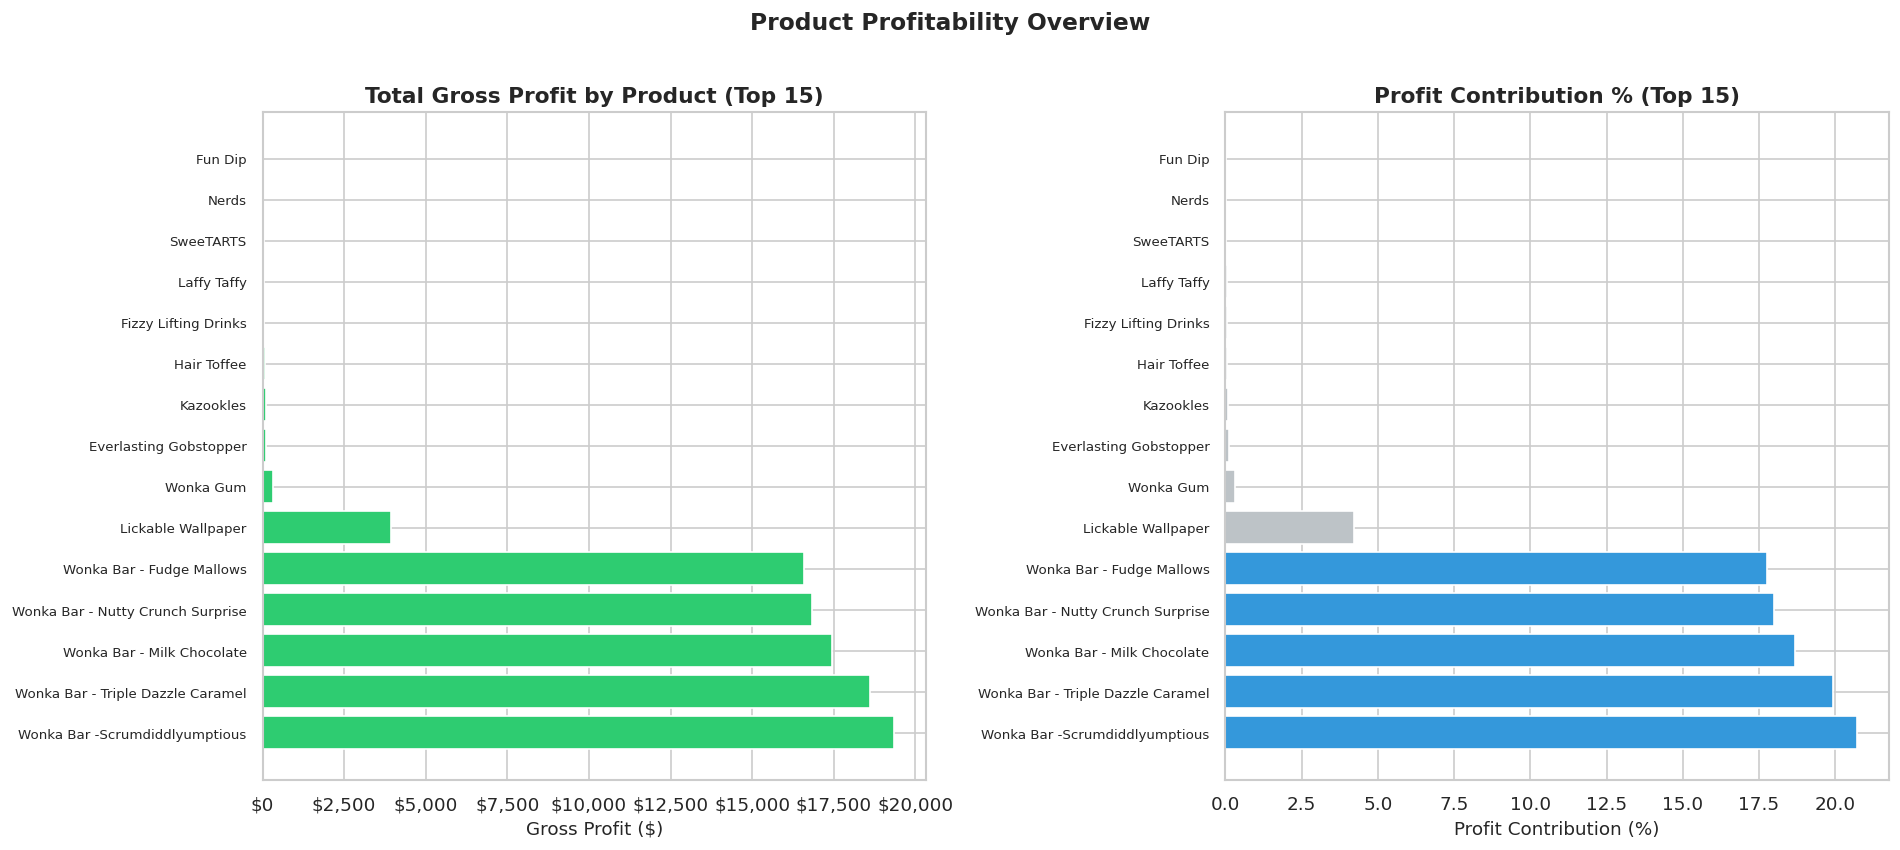

In [32]:
top15 = product_df.sort_values('Total_Profit', ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gross Profit bar
colors_p = ['#e74c3c' if v < 0 else '#2ecc71' for v in top15['Total_Profit']]
axes[0].barh(top15['Product Name'], top15['Total_Profit'], color=colors_p)
axes[0].set_title('Total Gross Profit by Product (Top 15)')
axes[0].set_xlabel('Gross Profit ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='y', labelsize=8)

# Profit Contribution %
avg_contrib = top15['Profit Contribution (%)'].mean()
axes[1].barh(top15['Product Name'], top15['Profit Contribution (%)'],
             color=['#3498db' if v >= avg_contrib else '#bdc3c7' for v in top15['Profit Contribution (%)']])
axes[1].set_title('Profit Contribution % (Top 15)')
axes[1].set_xlabel('Profit Contribution (%)')
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Product Profitability Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/product_profitability.png', bbox_inches='tight')
plt.show()


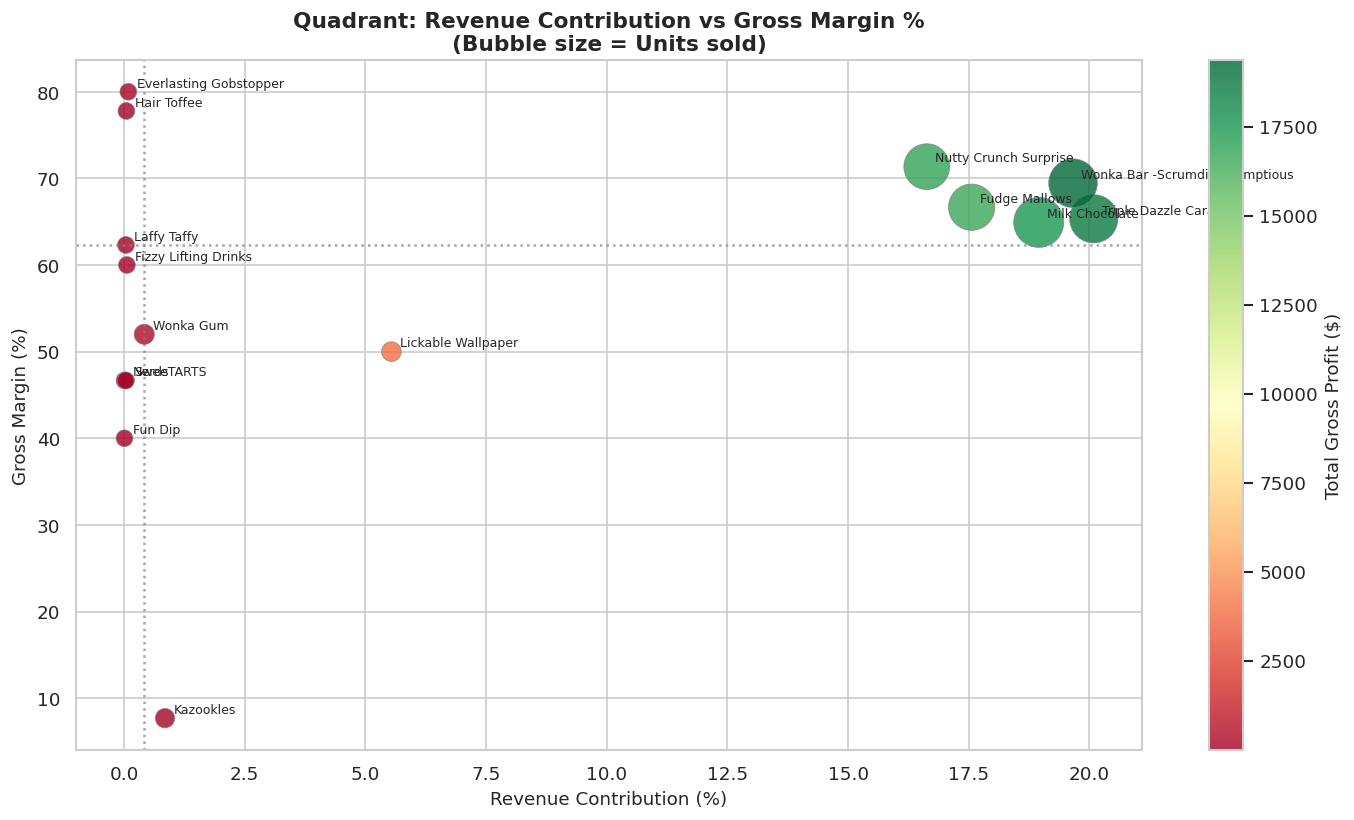

In [33]:
# Quadrant: Revenue Contribution vs Gross Margin %
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    product_df['Revenue Contribution (%)'], product_df['Gross Margin (%)'],
    s=product_df['Total_Units'] / product_df['Total_Units'].max() * 800 + 100,
    c=product_df['Total_Profit'], cmap='RdYlGn', alpha=0.8, edgecolors='grey', linewidth=0.5
)
plt.colorbar(scatter, label='Total Gross Profit ($)')
ax.axvline(product_df['Revenue Contribution (%)'].median(), color='grey', linestyle=':', alpha=0.7)
ax.axhline(product_df['Gross Margin (%)'].median(), color='grey', linestyle=':', alpha=0.7)
for _, row in product_df.iterrows():
    ax.annotate(row['Product Name'].split(' - ')[-1],
                xy=(row['Revenue Contribution (%)'], row['Gross Margin (%)']),
                xytext=(5, 3), textcoords='offset points', fontsize=7.5)
ax.set_xlabel('Revenue Contribution (%)')
ax.set_ylabel('Gross Margin (%)')
ax.set_title('Quadrant: Revenue Contribution vs Gross Margin %\n(Bubble size = Units sold)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/quadrant_analysis.png', bbox_inches='tight')
plt.show()


---
## 6️⃣ Division Performance Dashboard
### 🏭 Revenue vs Profit Comparison & Margin Distribution

In [34]:
division_df = df.groupby('Division').agg(
    Total_Sales     = ('Sales', 'sum'),
    Total_Profit    = ('Gross Profit', 'sum'),
    Total_Cost      = ('Cost', 'sum'),
    Total_Units     = ('Units', 'sum'),
    Unique_Products = ('Product Name', 'nunique'),
    Order_Count     = ('Order ID', 'nunique')
).reset_index()

division_df['Gross Margin (%)']  = (division_df['Total_Profit'] / division_df['Total_Sales'] * 100).round(2)
division_df['Revenue Share (%)'] = (division_df['Total_Sales']  / division_df['Total_Sales'].sum()  * 100).round(2)
division_df['Profit Share (%)']  = (division_df['Total_Profit'] / division_df['Total_Profit'].sum() * 100).round(2)
division_df['Profit per Unit']   = (division_df['Total_Profit'] / division_df['Total_Units']).round(4)
division_df['Margin Flag']       = division_df.apply(
    lambda r: '⚠ Margin Risk' if (r['Revenue Share (%)'] - r['Profit Share (%)']) >= 5 else '✅ Healthy', axis=1
)

print('DIVISION PERFORMANCE SUMMARY')
display(
    division_df[['Division', 'Total_Sales', 'Total_Profit', 'Gross Margin (%)',
                 'Revenue Share (%)', 'Profit Share (%)', 'Margin Flag']]
    .sort_values('Gross Margin (%)', ascending=False).reset_index(drop=True)
    .style.format({
        'Total_Sales': '${:,.2f}', 'Total_Profit': '${:,.2f}',
        'Gross Margin (%)': '{:.1f}%', 'Revenue Share (%)': '{:.1f}%', 'Profit Share (%)': '{:.1f}%'
    }).applymap(lambda v: 'color: red' if '⚠' in str(v) else '', subset=['Margin Flag'])
)


DIVISION PERFORMANCE SUMMARY


,Division,Total_Sales,Total_Profit,Gross Margin (%),Revenue Share (%),Profit Share (%),Margin Flag
0,Chocolate,"$131,692.90","$88,824.62",67.5%,92.9%,95.1%,✅ Healthy
1,Sugar,$427.48,$284.73,66.6%,0.3%,0.3%,✅ Healthy
2,Other,"$9,663.25","$4,333.45",44.8%,6.8%,4.6%,✅ Healthy


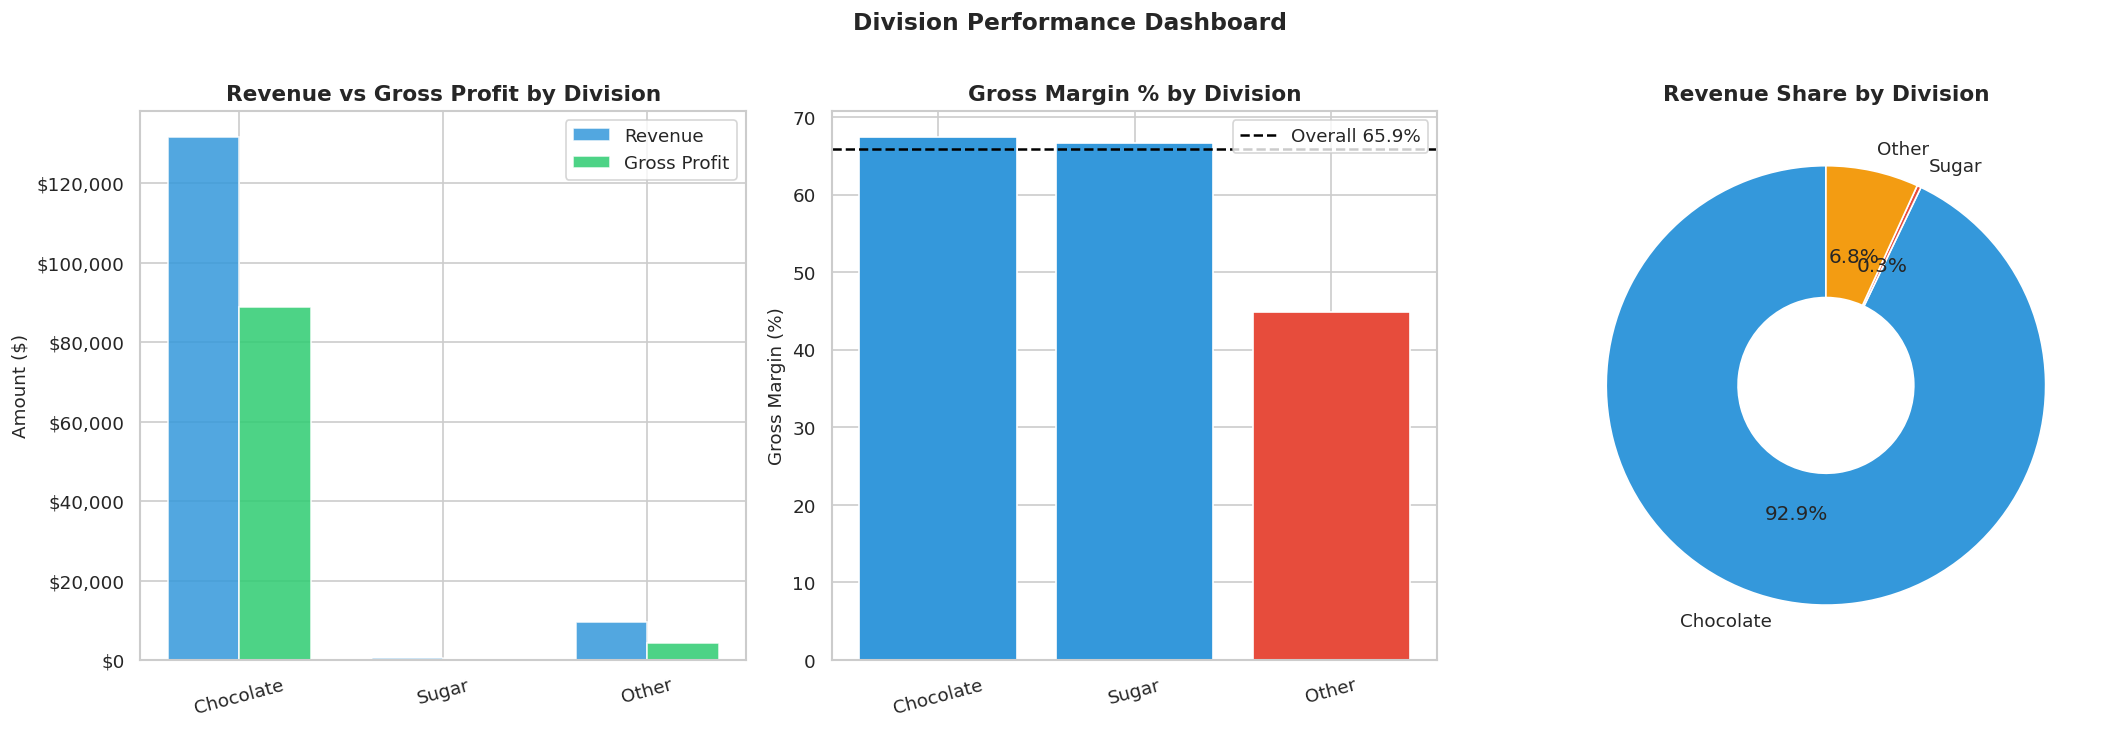

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
divs = division_df.sort_values('Gross Margin (%)', ascending=False)

x = np.arange(len(divs)); w = 0.35
axes[0].bar(x - w/2, divs['Total_Sales'],  w, label='Revenue',      color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, divs['Total_Profit'], w, label='Gross Profit', color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(divs['Division'], rotation=15)
axes[0].set_title('Revenue vs Gross Profit by Division')
axes[0].set_ylabel('Amount ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

bar_colors = ['#e74c3c' if v < overall_margin else '#3498db' for v in divs['Gross Margin (%)']]
axes[1].bar(divs['Division'], divs['Gross Margin (%)'], color=bar_colors)
axes[1].axhline(overall_margin, color='black', linestyle='--', linewidth=1.5, label=f'Overall {overall_margin:.1f}%')
axes[1].set_title('Gross Margin % by Division'); axes[1].set_ylabel('Gross Margin (%)')
axes[1].set_xticklabels(divs['Division'], rotation=15); axes[1].legend()

palette = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6']
axes[2].pie(divs['Revenue Share (%)'], labels=divs['Division'],
            colors=palette[:len(divs)], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.6, edgecolor='white'))
axes[2].set_title('Revenue Share by Division')

plt.suptitle('Division Performance Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/division_performance.png', bbox_inches='tight')
plt.show()


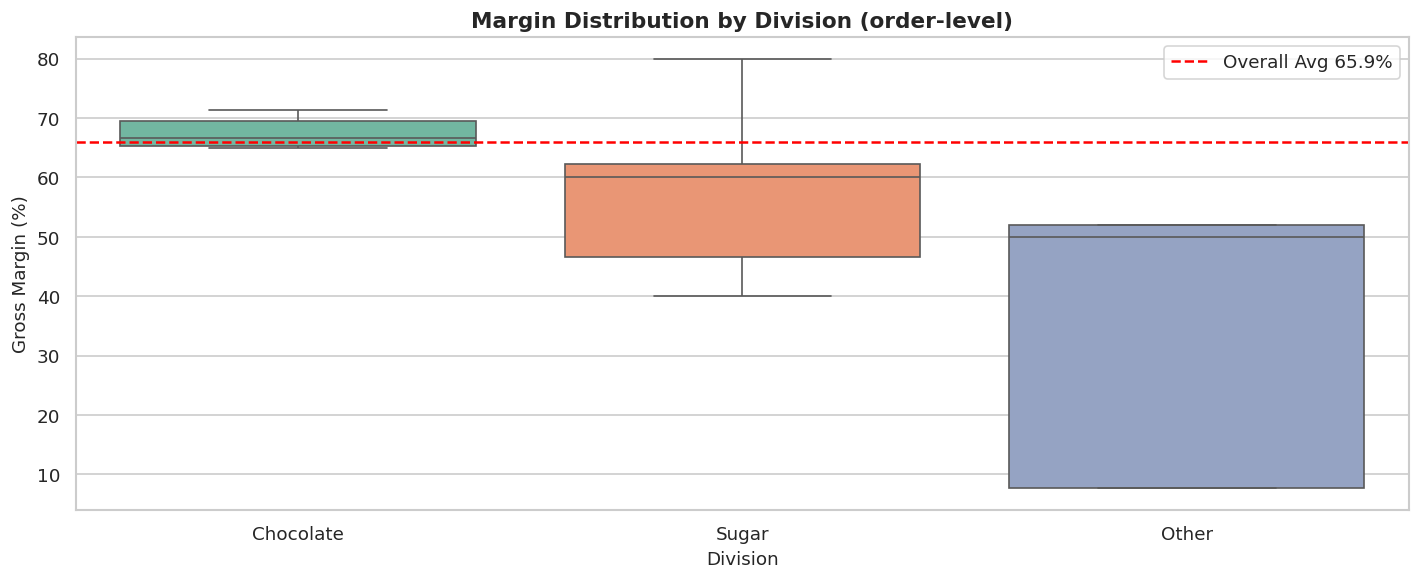

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
div_order = df.groupby('Division')['Gross Margin (%)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Division', y='Gross Margin (%)', order=div_order,
            palette='Set2', ax=ax, flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.axhline(overall_margin, color='red', linestyle='--', linewidth=1.5, label=f'Overall Avg {overall_margin:.1f}%')
ax.set_title('Margin Distribution by Division (order-level)', fontweight='bold')
ax.set_ylabel('Gross Margin (%)')
ax.legend(); plt.tight_layout()
plt.savefig('/content/margin_distribution.png', bbox_inches='tight')
plt.show()


---
## 7️⃣ Profit Concentration — Pareto Analysis
### 📊 Pareto Charts & Dependency Indicators

📊 Pareto Findings:
   5 products  → 80% of PROFIT  (33% of portfolio)
   5 products → 80% of REVENUE (33% of portfolio)

📌 Dependency Indicator:
   Top 5 products: 95.1% of total profit
   ⚠ HIGH concentration risk


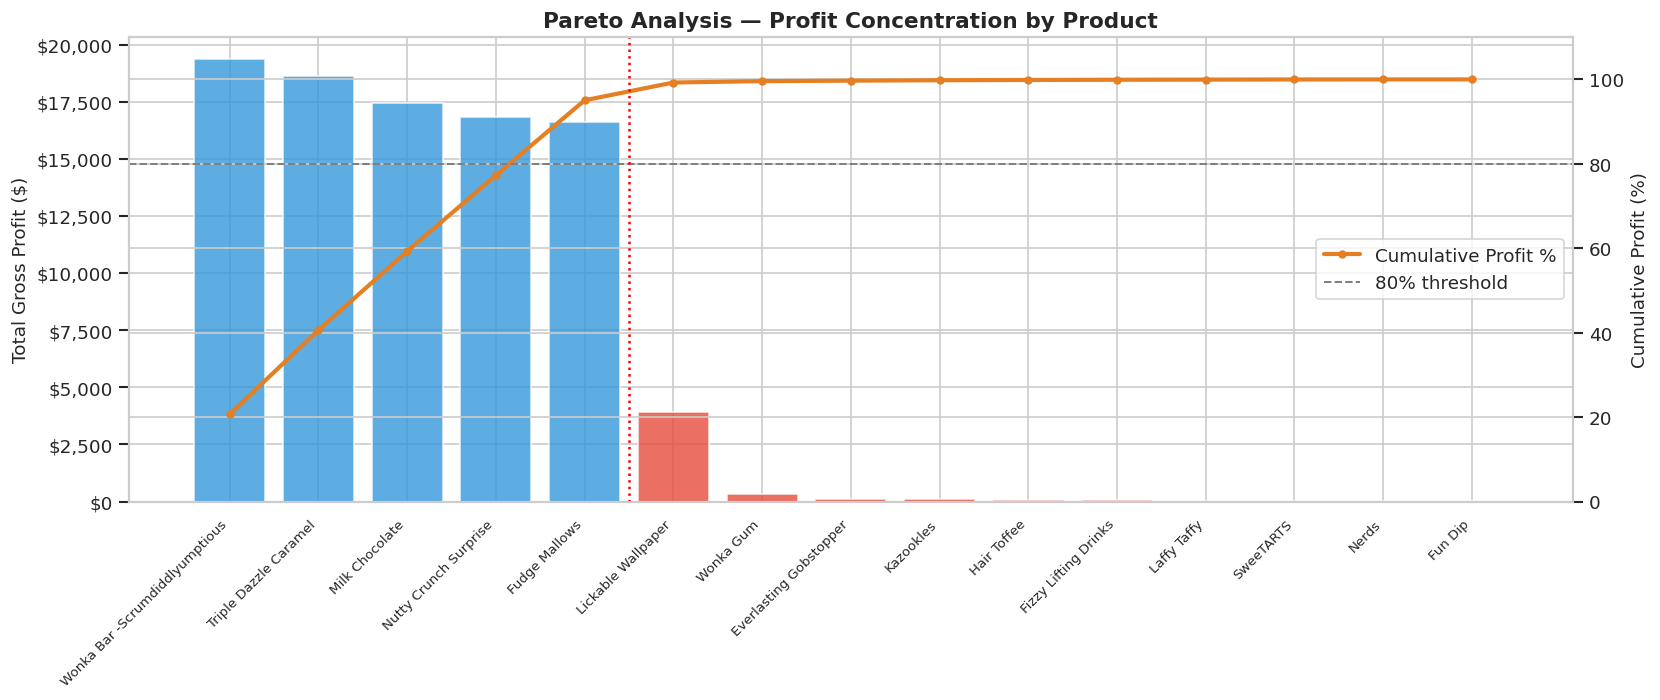

In [37]:
pareto = product_df.sort_values('Total_Profit', ascending=False).copy()
pareto['Cumulative Profit (%)']  = pareto['Total_Profit'].cumsum() / pareto['Total_Profit'].sum() * 100
pareto['Cumulative Revenue (%)'] = pareto['Total_Sales'].cumsum()  / pareto['Total_Sales'].sum()  * 100

profit_80_count  = (pareto['Cumulative Profit (%)'] <= 80).sum() + 1
revenue_80_count = (
    pareto.sort_values('Total_Sales', ascending=False)['Total_Sales']
    .cumsum() / pareto['Total_Sales'].sum() * 100 <= 80
).sum() + 1
top5_profit_share = pareto.head(5)['Profit Contribution (%)'].sum()

print(f'📊 Pareto Findings:')
print(f'   {profit_80_count} products  → 80% of PROFIT  ({profit_80_count/len(pareto)*100:.0f}% of portfolio)')
print(f'   {revenue_80_count} products → 80% of REVENUE ({revenue_80_count/len(pareto)*100:.0f}% of portfolio)')
print(f'\n📌 Dependency Indicator:')
print(f'   Top 5 products: {top5_profit_share:.1f}% of total profit')
if top5_profit_share > 60:
    print('   ⚠ HIGH concentration risk')
elif top5_profit_share > 40:
    print('   🟡 MODERATE concentration')
else:
    print('   ✅ Healthy diversification')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
bar_colors = ['#3498db' if i < profit_80_count else '#e74c3c' for i in range(len(pareto))]
ax1.bar(range(len(pareto)), pareto['Total_Profit'], color=bar_colors, alpha=0.8)
ax2.plot(range(len(pareto)), pareto['Cumulative Profit (%)'], color='#e67e22', linewidth=2.5,
         marker='o', markersize=4, label='Cumulative Profit %')
ax2.axhline(80, color='grey', linestyle='--', linewidth=1.2, label='80% threshold')
ax2.axvline(profit_80_count - 0.5, color='red', linestyle=':', linewidth=1.5)
ax1.set_xticks(range(len(pareto)))
ax1.set_xticklabels([n.split(' - ')[-1] for n in pareto['Product Name']], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Total Gross Profit ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylabel('Cumulative Profit (%)'); ax2.set_ylim(0, 110); ax2.legend(loc='center right')
plt.title('Pareto Analysis — Profit Concentration by Product', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/pareto_analysis.png', bbox_inches='tight')
plt.show()


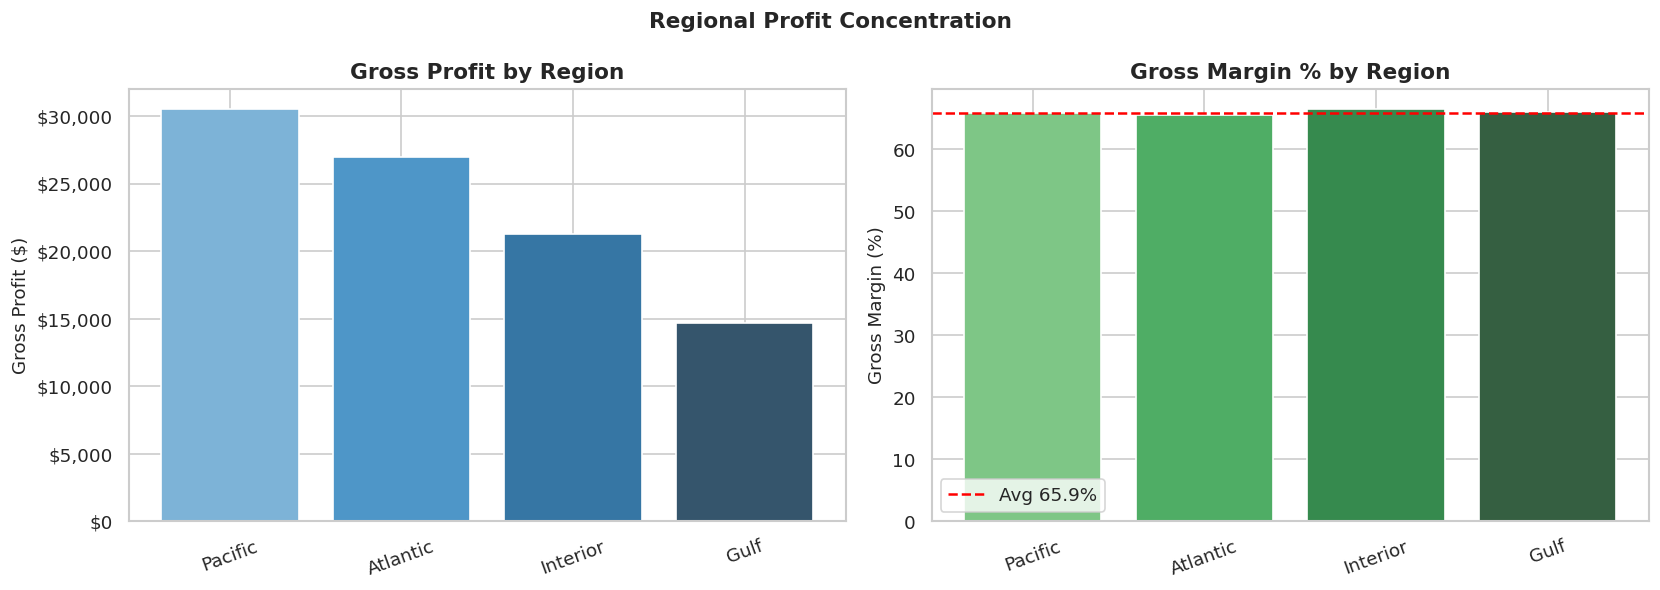

In [38]:
region_df = df.groupby('Region').agg(Total_Sales=('Sales','sum'), Total_Profit=('Gross Profit','sum')).reset_index()
region_df['Margin (%)'] = (region_df['Total_Profit'] / region_df['Total_Sales'] * 100).round(2)
region_sorted = region_df.sort_values('Total_Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(region_sorted['Region'], region_sorted['Total_Profit'], color=sns.color_palette('Blues_d', len(region_sorted)))
axes[0].set_title('Gross Profit by Region'); axes[0].set_ylabel('Gross Profit ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(region_sorted['Region'], region_sorted['Margin (%)'], color=sns.color_palette('Greens_d', len(region_sorted)))
axes[1].axhline(overall_margin, color='red', linestyle='--', linewidth=1.5, label=f'Avg {overall_margin:.1f}%')
axes[1].set_title('Gross Margin % by Region'); axes[1].set_ylabel('Gross Margin (%)')
axes[1].tick_params(axis='x', rotation=20); axes[1].legend()

plt.suptitle('Regional Profit Concentration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/region_profit.png', bbox_inches='tight')
plt.show()


---
## 8️⃣ Cost vs Margin Diagnostics
### 💰 Cost-Sales Scatter Plots & Margin Risk Flags

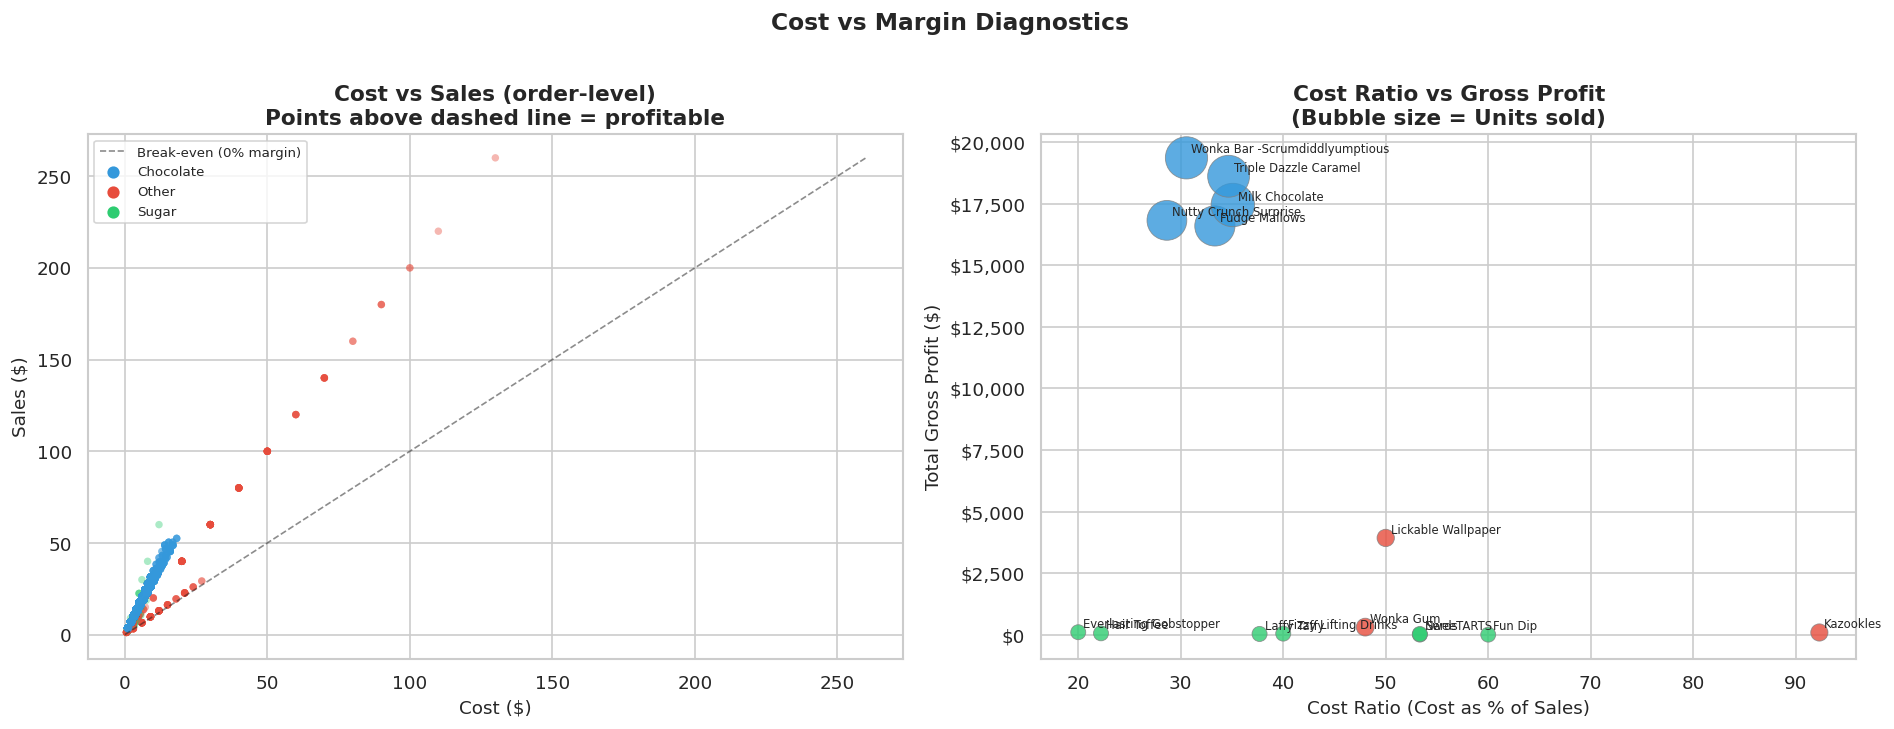

In [39]:
div_colors = {d: c for d, c in zip(df['Division'].unique(),
              ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])}
colors = df['Division'].map(div_colors)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['Cost'], df['Sales'], c=colors, alpha=0.4, s=20, edgecolors='none')
max_val = max(df['Cost'].max(), df['Sales'].max())
axes[0].plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Break-even (0% margin)')
for div, col in div_colors.items():
    axes[0].scatter([], [], c=col, label=div, s=40)
axes[0].set_xlabel('Cost ($)'); axes[0].set_ylabel('Sales ($)')
axes[0].set_title('Cost vs Sales (order-level)\nPoints above dashed line = profitable')
axes[0].legend(fontsize=8)

axes[1].scatter(product_df['Cost Ratio (%)'], product_df['Total_Profit'],
                c=[div_colors.get(d, 'grey') for d in product_df['Division']],
                s=product_df['Total_Units'] / product_df['Total_Units'].max() * 600 + 80,
                alpha=0.8, edgecolors='grey', linewidth=0.5)
for _, row in product_df.iterrows():
    axes[1].annotate(row['Product Name'].split(' - ')[-1],
                     xy=(row['Cost Ratio (%)'], row['Total_Profit']),
                     xytext=(3, 3), textcoords='offset points', fontsize=7)
axes[1].set_xlabel('Cost Ratio (Cost as % of Sales)'); axes[1].set_ylabel('Total Gross Profit ($)')
axes[1].set_title('Cost Ratio vs Gross Profit\n(Bubble size = Units sold)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Cost vs Margin Diagnostics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/cost_diagnostics.png', bbox_inches='tight')
plt.show()


In [40]:
low_margin_threshold  = overall_margin - 10
high_margin_threshold = overall_margin + 10

def flag_product(row):
    if row['Gross Margin (%)'] < low_margin_threshold:
        return '🔴 Low Margin — Review'
    elif row['Gross Margin (%)'] > high_margin_threshold:
        return '🟢 High Margin — Promote'
    return '🟡 Average'

product_df['Margin Flag'] = product_df.apply(flag_product, axis=1)
risk_products = product_df[product_df['Margin Flag'] == '🔴 Low Margin — Review']
star_products = product_df[product_df['Margin Flag'] == '🟢 High Margin — Promote']

print(f'Thresholds: Low < {low_margin_threshold:.1f}%  |  High > {high_margin_threshold:.1f}%\n')
print(f'🔴 LOW MARGIN PRODUCTS ({len(risk_products)}):')
if len(risk_products):
    display(risk_products[['Product Name','Division','Total_Sales','Total_Profit',
                            'Gross Margin (%)','Cost Ratio (%)','Margin Volatility']]
            .sort_values('Gross Margin (%)').reset_index(drop=True)
            .style.format({'Total_Sales':'${:,.2f}','Total_Profit':'${:,.2f}',
                           'Gross Margin (%)':'{:.1f}%','Cost Ratio (%)':'{:.1f}%','Margin Volatility':'{:.2f}'}))
print(f'\n🟢 HIGH MARGIN PRODUCTS ({len(star_products)}):')
if len(star_products):
    display(star_products[['Product Name','Division','Total_Sales','Total_Profit',
                            'Gross Margin (%)','Cost Ratio (%)','Margin Volatility']]
            .sort_values('Gross Margin (%)', ascending=False).reset_index(drop=True)
            .style.format({'Total_Sales':'${:,.2f}','Total_Profit':'${:,.2f}',
                           'Gross Margin (%)':'{:.1f}%','Cost Ratio (%)':'{:.1f}%','Margin Volatility':'{:.2f}'}))


Thresholds: Low < 55.9%  |  High > 75.9%

🔴 LOW MARGIN PRODUCTS (6):


,Product Name,Division,Total_Sales,Total_Profit,Gross Margin (%),Cost Ratio (%),Margin Volatility
0,Kazookles,Other,"$1,205.75",$92.75,7.7%,92.3%,0.00
1,Fun Dip,Sugar,$12.00,$4.80,40.0%,60.0%,0.00
2,SweeTARTS,Sugar,$61.50,$28.70,46.7%,53.3%,0.00
3,Nerds,Sugar,$15.00,$7.00,46.7%,53.3%,0.00
4,Lickable Wallpaper,Other,"$7,860.00","$3,930.00",50.0%,50.0%,0.00
5,Wonka Gum,Other,$597.50,$310.70,52.0%,48.0%,0.00



🟢 HIGH MARGIN PRODUCTS (2):


,Product Name,Division,Total_Sales,Total_Profit,Gross Margin (%),Cost Ratio (%),Margin Volatility
0,Everlasting Gobstopper,Sugar,$130.00,$104.00,80.0%,20.0%,0.00
1,Hair Toffee,Sugar,$76.50,$59.50,77.8%,22.2%,0.00


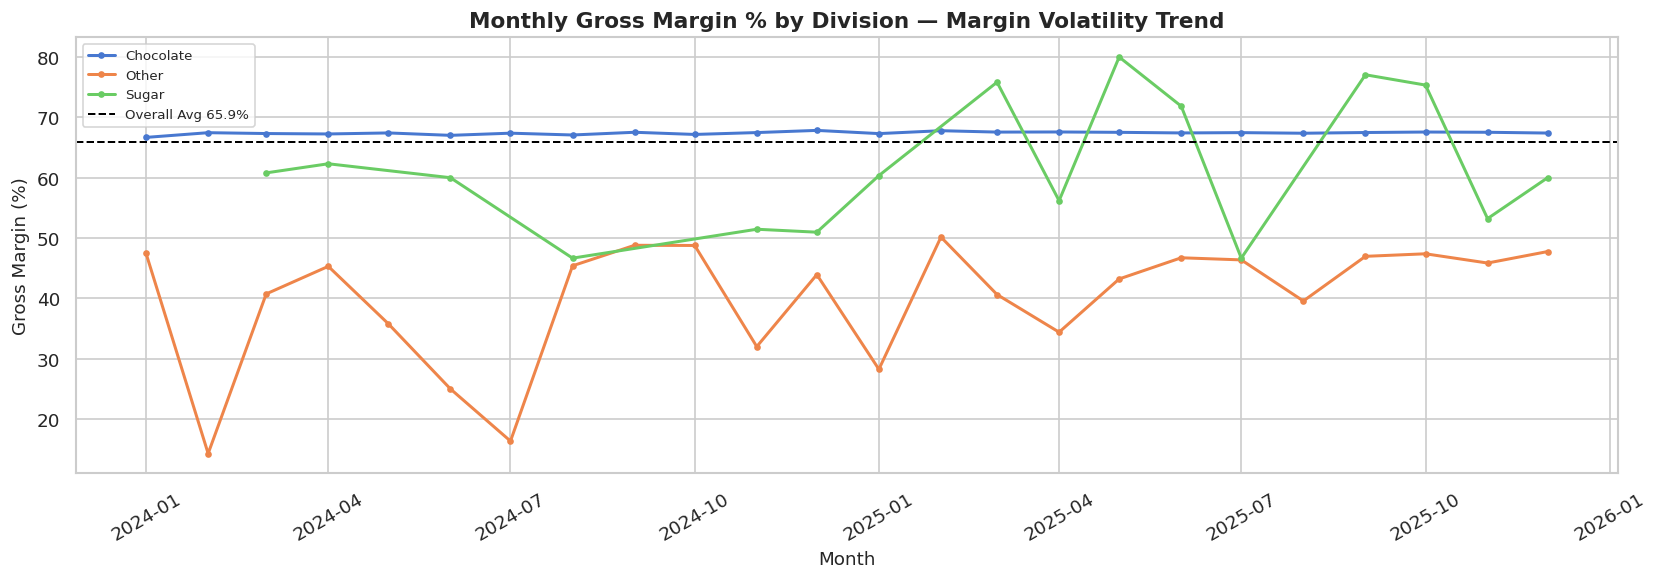


📊 TOP 10 MOST VOLATILE PRODUCTS:


,Product Name,Division,Gross Margin (%),Margin Volatility
0,Wonka Bar - Fudge Mallows,Chocolate,66.7%,0.00
1,Wonka Bar - Milk Chocolate,Chocolate,64.9%,0.00
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,71.3%,0.00
3,Wonka Bar - Triple Dazzle Caramel,Chocolate,65.3%,0.00
4,Wonka Bar -Scrumdiddlyumptious,Chocolate,69.4%,0.00
5,Kazookles,Other,7.7%,0.00
6,Lickable Wallpaper,Other,50.0%,0.00
7,Wonka Gum,Other,52.0%,0.00
8,Everlasting Gobstopper,Sugar,80.0%,0.00
9,Fizzy Lifting Drinks,Sugar,60.0%,0.00


In [41]:
monthly_df = df.groupby(['Month', 'Division']).agg(
    Monthly_Sales=('Sales','sum'), Monthly_Profit=('Gross Profit','sum')).reset_index()
monthly_df['Monthly Margin (%)'] = (monthly_df['Monthly_Profit'] / monthly_df['Monthly_Sales'] * 100).round(2)
monthly_df['Month_DT'] = monthly_df['Month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for div in monthly_df['Division'].unique():
    sub = monthly_df[monthly_df['Division'] == div].sort_values('Month_DT')
    ax.plot(sub['Month_DT'], sub['Monthly Margin (%)'], marker='o', markersize=3, label=div, linewidth=1.8)
ax.axhline(overall_margin, color='black', linestyle='--', linewidth=1.2, label=f'Overall Avg {overall_margin:.1f}%')
ax.set_title('Monthly Gross Margin % by Division — Margin Volatility Trend', fontweight='bold')
ax.set_ylabel('Gross Margin (%)'); ax.set_xlabel('Month'); ax.legend(fontsize=8)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('/content/margin_trend.png', bbox_inches='tight')
plt.show()

print('\n📊 TOP 10 MOST VOLATILE PRODUCTS:')
display(
    product_df[['Product Name','Division','Gross Margin (%)','Margin Volatility']]
    .sort_values('Margin Volatility', ascending=False).head(10).reset_index(drop=True)
    .style.format({'Gross Margin (%)':'{:.1f}%','Margin Volatility':'{:.2f}'})
    .background_gradient(subset='Margin Volatility', cmap='Oranges')
)


---
## 9️⃣ Key Insights & Recommendations

In [42]:
top_product_profit = product_df.sort_values('Total_Profit', ascending=False).iloc[0]
top_product_margin = product_df.sort_values('Gross Margin (%)', ascending=False).iloc[0]
worst_margin_prod  = product_df.sort_values('Gross Margin (%)').iloc[0]
most_volatile_prod = product_df.sort_values('Margin Volatility', ascending=False).iloc[0]
top_division       = division_df.sort_values('Gross Margin (%)', ascending=False).iloc[0]
worst_division     = division_df.sort_values('Gross Margin (%)').iloc[0]

print('=' * 65)
print('  KEY ANALYTICAL INSIGHTS — Nassau Candy Distributor')
print('=' * 65)
print(f"""
📌 OVERALL PERFORMANCE
   Gross Margin (%)        : {overall_margin:.1f}%
   Total Revenue           : ${total_sales:,.2f}
   Total Gross Profit      : ${total_profit:,.2f}

📌 PRODUCT INSIGHTS
   Highest Profit Product  : {top_product_profit['Product Name']}  (${top_product_profit['Total_Profit']:,.2f})
   Highest Margin Product  : {top_product_margin['Product Name']}  ({top_product_margin['Gross Margin (%)']:.1f}%)
   Lowest Margin Product   : {worst_margin_prod['Product Name']}   ({worst_margin_prod['Gross Margin (%)']:.1f}%)
   Most Volatile Product   : {most_volatile_prod['Product Name']}  (σ={most_volatile_prod['Margin Volatility']:.2f}%)
   Low-margin risk count   : {len(risk_products)} products

📌 DIVISION INSIGHTS
   Best Margin Division    : {top_division['Division']} ({top_division['Gross Margin (%)']:.1f}%)
   Weakest Division        : {worst_division['Division']} ({worst_division['Gross Margin (%)']:.1f}%)

📌 PARETO FINDINGS
   {profit_80_count} products → 80% of gross profit
   {revenue_80_count} products → 80% of revenue
   Top 5 products: {top5_profit_share:.1f}% profit concentration

📌 STRATEGIC RECOMMENDATIONS
   1. PROMOTE high-margin products (🟢) — expand via targeted marketing
   2. INVESTIGATE low-margin products (🔴): reprice or renegotiate COGS
   3. AUDIT cost structure of {worst_division['Division']} — margin lags overall
   4. PROTECT top {profit_80_count} profit-driving products from supply disruptions
   5. MONITOR high-volatility products — pricing inconsistency signals issues
   6. REVIEW products below {low_margin_threshold:.1f}% margin for discontinuation
""")
print('=' * 65)


  KEY ANALYTICAL INSIGHTS — Nassau Candy Distributor

📌 OVERALL PERFORMANCE
   Gross Margin (%)        : 65.9%
   Total Revenue           : $141,783.63
   Total Gross Profit      : $93,442.80

📌 PRODUCT INSIGHTS
   Highest Profit Product  : Wonka Bar -Scrumdiddlyumptious  ($19,357.50)
   Highest Margin Product  : Everlasting Gobstopper  (80.0%)
   Lowest Margin Product   : Kazookles   (7.7%)
   Most Volatile Product   : Wonka Bar - Fudge Mallows  (σ=0.00%)
   Low-margin risk count   : 6 products

📌 DIVISION INSIGHTS
   Best Margin Division    : Chocolate (67.5%)
   Weakest Division        : Other (44.8%)

📌 PARETO FINDINGS
   5 products → 80% of gross profit
   5 products → 80% of revenue
   Top 5 products: 95.1% profit concentration

📌 STRATEGIC RECOMMENDATIONS
   1. PROMOTE high-margin products (🟢) — expand via targeted marketing
   2. INVESTIGATE low-margin products (🔴): reprice or renegotiate COGS
   3. AUDIT cost structure of Other — margin lags overall
   4. PROTECT top 5 profit-

In [43]:
# Check actual month-level margins for a product
test = df.groupby(['Product Name', 'Month'])['Gross Margin (%)'].mean().reset_index()
print(test.groupby('Product Name')['Gross Margin (%)'].std().sort_values(ascending=False).head(10))

Product Name
Kazookles                    1.893603e-16
Fizzy Lifting Drinks         0.000000e+00
Everlasting Gobstopper       0.000000e+00
Fun Dip                      0.000000e+00
Hair Toffee                  0.000000e+00
Laffy Taffy                  0.000000e+00
Lickable Wallpaper           0.000000e+00
Nerds                        0.000000e+00
SweeTARTS                    0.000000e+00
Wonka Bar - Fudge Mallows    0.000000e+00
Name: Gross Margin (%), dtype: float64


---
## 🔟 Streamlit Dashboard


### User Capabilities
| Control | Description |
|---------|-------------|
| 📅 Date range selector | Filter orders by date |
| 🏭 Division filter | Multi-select divisions |
| 📉 Margin threshold slider | Highlight products above/below a margin % |
| 🔍 Product search | Filters all charts & tables correctly |


In [44]:
import re

app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob

st.set_page_config(page_title="Nassau Candy - Profitability Dashboard", layout="wide")

@st.cache_data
def load_data():
    csv_files = glob.glob("/content/*.csv")
    if not csv_files:
        st.error("No CSV found in /content/. Run the Upload cell first.")
        st.stop()
    df = pd.read_csv(csv_files[0])
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
    df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True, errors="coerce")
    df = df[df["Sales"] > 0].copy()
    df["Product Name"] = df["Product Name"].str.strip().str.replace(r"\\s+", " ", regex=True)
    df["Gross Margin (%)"] = (df["Gross Profit"] / df["Sales"] * 100).round(2)
    df["Profit per Unit"]  = (df["Gross Profit"] / df["Units"]).round(4)
    df["Month"] = df["Order Date"].dt.to_period("M")
    return df

df_raw = load_data()

st.sidebar.title("Filters")
min_date = df_raw["Order Date"].min().date()
max_date = df_raw["Order Date"].max().date()
date_range = st.sidebar.date_input("Date Range", value=(min_date, max_date), min_value=min_date, max_value=max_date)
all_divs = sorted(df_raw["Division"].dropna().unique())
sel_divs = st.sidebar.multiselect("Division", all_divs, default=all_divs)
margin_thresh = st.sidebar.slider("Margin Threshold (%)", 0, 100, 50)
product_search = st.sidebar.text_input("Product Search", placeholder="e.g. Gummy Bear")

df = df_raw.copy()
if len(date_range) == 2:
    df = df[(df["Order Date"].dt.date >= date_range[0]) & (df["Order Date"].dt.date <= date_range[1])]
if sel_divs:
    df = df[df["Division"].isin(sel_divs)]
if product_search.strip():
    df = df[df["Product Name"].str.contains(product_search.strip(), case=False, na=False)]

if df.empty:
    st.warning("No data matches filters. Adjust the sidebar.")
    st.stop()

def build_product_df(data):
    p = data.groupby(["Division", "Product Name"]).agg(
        Total_Sales=("Sales","sum"), Total_Profit=("Gross Profit","sum"),
        Total_Cost=("Cost","sum"),   Total_Units=("Units","sum")
    ).reset_index()
    ts, tp = p["Total_Sales"].sum(), p["Total_Profit"].sum()
    p["Gross Margin (%)"]         = (p["Total_Profit"] / p["Total_Sales"] * 100).round(2)
    p["Profit per Unit"]          = (p["Total_Profit"] / p["Total_Units"]).round(4)
    p["Cost Ratio (%)"]           = (p["Total_Cost"]   / p["Total_Sales"] * 100).round(2)
    p["Revenue Contribution (%)"] = (p["Total_Sales"]  / ts * 100).round(2)
    p["Profit Contribution (%)"]  = (p["Total_Profit"] / tp * 100).round(2)
    vol = data.groupby(["Product Name","Month"])["Gross Margin (%)"].mean().reset_index()
    vol = vol.groupby("Product Name")["Gross Margin (%)"].agg(
        Margin_Volatility=lambda x: x.max() - x.min()
    ).reset_index()
    vol.columns = ["Product Name", "Margin Volatility"]
    p = p.merge(vol, on="Product Name", how="left")
    p["Margin Volatility"] = p["Margin Volatility"].round(2).fillna(0)
    return p

def build_division_df(data):
    d = data.groupby("Division").agg(
        Total_Sales=("Sales","sum"), Total_Profit=("Gross Profit","sum"),
        Total_Cost=("Cost","sum"),   Total_Units=("Units","sum")
    ).reset_index()
    d["Gross Margin (%)"]  = (d["Total_Profit"] / d["Total_Sales"] * 100).round(2)
    d["Revenue Share (%)"] = (d["Total_Sales"]  / d["Total_Sales"].sum()  * 100).round(2)
    d["Profit Share (%)"]  = (d["Total_Profit"] / d["Total_Profit"].sum() * 100).round(2)
    return d

product_df  = build_product_df(df)
division_df = build_division_df(df)
total_sales    = df["Sales"].sum()
total_profit   = df["Gross Profit"].sum()
overall_margin = total_profit / total_sales * 100 if total_sales > 0 else 0

st.sidebar.markdown("---")
st.sidebar.markdown(f"### {len(product_df)} Products in NASSAU CANDY")
for p in sorted(product_df["Product Name"].unique()):
    st.sidebar.markdown(f"- {p}")

st.title("Nassau Candy Distributor")
st.subheader("Product Line Profitability & Margin Performance Dashboard")
if product_search.strip():
    st.info(f\'Filtering by: "{product_search.strip()}" - {product_df["Product Name"].nunique()} product(s) matched\')
st.divider()

k1,k2,k3,k4,k5,k6 = st.columns(6)
k1.metric("Gross Margin (%)", f"{overall_margin:.1f}%")
k2.metric("Profit per Unit",  f"${total_profit/df['Units'].sum():.4f}" if df["Units"].sum()>0 else "N/A")
k3.metric("Revenue",          f"${total_sales:,.0f}")
k4.metric("Profit",           f"${total_profit:,.0f}")
k5.metric("Units Sold",       f"{int(df['Units'].sum()):,}")
vol_val = product_df["Margin Volatility"].mean()
k6.metric("Avg Margin Volatility", f"{vol_val:.2f}%" if not pd.isna(vol_val) else "N/A")
st.divider()

tab1,tab2,tab3,tab4,tab5 = st.tabs(["Product Profitability","Division Performance","Cost & Margin Diagnostics","Pareto Concentration","Findings"])

with tab1:
    st.subheader("Product-Level Margin Leaderboard")
    sort_by = st.selectbox("Sort by",["Total_Profit","Gross Margin (%)","Total_Sales","Profit per Unit","Revenue Contribution (%)","Profit Contribution (%)"])
    n_products = len(product_df)
    if n_products > 1:
        top_n = st.slider("Show top N", 1, n_products, min(10, n_products), key="t1")
    else:
        top_n = 1
        st.info("Showing 1 matched product")
    sp = product_df.sort_values(sort_by, ascending=False).head(top_n)
    fig_h = max(4, top_n * 0.55)
    c1,c2 = st.columns(2)
    with c1:
        fig,ax = plt.subplots(figsize=(8, fig_h))
        colors = ["#2ecc71" if m >= margin_thresh else "#e74c3c" for m in sp["Gross Margin (%)"]]
        ax.barh(sp["Product Name"], sp["Total_Profit"], color=colors)
        ax.set_xlabel("Total Gross Profit ($)")
        ax.set_title("Gross Profit by Product")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
        for i,v in enumerate(sp["Total_Profit"]):
            ax.text(v, i, f" ${v:,.0f}", va="center", fontsize=9)
        plt.tight_layout(); st.pyplot(fig); plt.close()
    with c2:
        fig,ax = plt.subplots(figsize=(8, fig_h))
        avg = sp["Profit Contribution (%)"].mean()
        bar_colors = ["#3498db" if v >= avg else "#bdc3c7" for v in sp["Profit Contribution (%)"]]
        ax.barh(sp["Product Name"], sp["Profit Contribution (%)"], color=bar_colors)
        ax.set_xlabel("Profit Contribution (%)")
        ax.set_title("Profit Contribution %")
        for i,v in enumerate(sp["Profit Contribution (%)"]):
            ax.text(v, i, f" {v:.1f}%", va="center", fontsize=9)
        plt.tight_layout(); st.pyplot(fig); plt.close()
    st.dataframe(
        sp[["Product Name","Division","Total_Sales","Total_Profit","Gross Margin (%)","Profit per Unit","Revenue Contribution (%)","Profit Contribution (%)","Margin Volatility"]]
        .style.format({"Total_Sales":"${:,.2f}","Total_Profit":"${:,.2f}","Gross Margin (%)":"{:.1f}%","Profit per Unit":"${:.4f}","Revenue Contribution (%)":"{:.1f}%","Profit Contribution (%)":"{:.1f}%","Margin Volatility":"{:.2f}"})
        .background_gradient(subset="Gross Margin (%)", cmap="RdYlGn"),
        use_container_width=True
    )

with tab2:
    st.subheader("Revenue vs Profit Comparison")
    ds = division_df.sort_values("Gross Margin (%)", ascending=False)
    c1,c2 = st.columns(2)
    with c1:
        fig,ax = plt.subplots(figsize=(8,5))
        x = np.arange(len(ds)); w = 0.35
        ax.bar(x-w/2, ds["Total_Sales"],  w, label="Revenue",      color="#3498db", alpha=0.85)
        ax.bar(x+w/2, ds["Total_Profit"], w, label="Gross Profit", color="#2ecc71", alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(ds["Division"], rotation=15)
        ax.set_ylabel("Amount ($)"); ax.set_title("Revenue vs Gross Profit")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
        ax.legend(); plt.tight_layout(); st.pyplot(fig); plt.close()
    with c2:
        fig,ax = plt.subplots(figsize=(8,5))
        colors = ["#e74c3c" if m < overall_margin else "#3498db" for m in ds["Gross Margin (%)"]]
        ax.bar(ds["Division"], ds["Gross Margin (%)"], color=colors)
        ax.axhline(overall_margin, color="black", linestyle="--", linewidth=1.5, label=f"Overall {overall_margin:.1f}%")
        ax.set_title("Gross Margin % by Division"); ax.set_ylabel("Gross Margin (%)")
        ax.set_xticklabels(ds["Division"], rotation=15); ax.legend()
        plt.tight_layout(); st.pyplot(fig); plt.close()
    st.subheader("Margin Distribution by Division")
    if df["Division"].nunique() > 1:
        fig,ax = plt.subplots(figsize=(12,4))
        div_order = df.groupby("Division")["Gross Margin (%)"].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x="Division", y="Gross Margin (%)", order=div_order, palette="Set2", ax=ax,
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))
        ax.axhline(overall_margin, color="red", linestyle="--", linewidth=1.5, label=f"Avg {overall_margin:.1f}%")
        ax.legend(); plt.tight_layout(); st.pyplot(fig); plt.close()
    else:
        st.info("Select multiple divisions to see the distribution.")
    st.dataframe(
        ds[["Division","Total_Sales","Total_Profit","Gross Margin (%)","Revenue Share (%)","Profit Share (%)"]]
        .style.format({"Total_Sales":"${:,.2f}","Total_Profit":"${:,.2f}","Gross Margin (%)":"{:.1f}%","Revenue Share (%)":"{:.1f}%","Profit Share (%)":"{:.1f}%"})
        .background_gradient(subset="Gross Margin (%)", cmap="RdYlGn"),
        use_container_width=True
    )

with tab3:
    st.subheader("Cost-Sales Scatter Plots")
    dp = {d:c for d,c in zip(df["Division"].unique(), ["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6"])}
    c1,c2 = st.columns(2)
    with c1:
        fig,ax = plt.subplots(figsize=(7,5))
        ax.scatter(df["Cost"], df["Sales"], c=df["Division"].map(dp), alpha=0.35, s=15, edgecolors="none")
        mv = max(df["Cost"].max(), df["Sales"].max())
        ax.plot([0,mv],[0,mv], "k--", linewidth=1, alpha=0.5, label="Break-even")
        for div,col in dp.items(): ax.scatter([],[],c=col,label=div,s=40)
        ax.set_xlabel("Cost ($)"); ax.set_ylabel("Sales ($)"); ax.set_title("Cost vs Sales")
        ax.legend(fontsize=7); plt.tight_layout(); st.pyplot(fig); plt.close()
    with c2:
        fig,ax = plt.subplots(figsize=(7,5))
        ax.scatter(product_df["Cost Ratio (%)"], product_df["Total_Profit"],
                   c=[dp.get(d,"grey") for d in product_df["Division"]],
                   s=product_df["Total_Units"]/product_df["Total_Units"].max()*600+60,
                   alpha=0.8, edgecolors="grey", linewidth=0.5)
        for _,row in product_df.iterrows():
            ax.annotate(row["Product Name"].split(" - ")[-1],
                        xy=(row["Cost Ratio (%)"],row["Total_Profit"]),
                        xytext=(3,3), textcoords="offset points", fontsize=7)
        ax.set_xlabel("Cost Ratio (%)"); ax.set_ylabel("Total Gross Profit ($)"); ax.set_title("Cost Ratio vs Gross Profit")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
        plt.tight_layout(); st.pyplot(fig); plt.close()
    st.subheader("Monthly Margin Volatility Trend")
    m = df.groupby(["Month","Division"]).agg(S=("Sales","sum"),P=("Gross Profit","sum")).reset_index()
    m["Margin"] = m["P"]/m["S"]*100
    m["Month_DT"] = m["Month"].dt.to_timestamp()
    fig,ax = plt.subplots(figsize=(12,4))
    for div in m["Division"].unique():
        sub = m[m["Division"]==div].sort_values("Month_DT")
        ax.plot(sub["Month_DT"], sub["Margin"], marker="o", markersize=3, label=div, linewidth=1.8)
    ax.axhline(overall_margin, color="black", linestyle="--", linewidth=1.2, label=f"Overall {overall_margin:.1f}%")
    ax.set_ylabel("Gross Margin (%)"); ax.legend(fontsize=8); plt.xticks(rotation=30)
    plt.tight_layout(); st.pyplot(fig); plt.close()
    st.subheader("Margin Risk Flags")
    risk = product_df[product_df["Gross Margin (%)"] < overall_margin-10].sort_values("Gross Margin (%)")
    if len(risk):
        st.dataframe(
            risk[["Product Name","Division","Total_Sales","Total_Profit","Gross Margin (%)","Cost Ratio (%)","Margin Volatility"]]
            .style.format({"Total_Sales":"${:,.2f}","Total_Profit":"${:,.2f}","Gross Margin (%)":"{:.1f}%","Cost Ratio (%)":"{:.1f}%","Margin Volatility":"{:.2f}"})
            .applymap(lambda _: "background-color:#ffe0e0"),
            use_container_width=True
        )
    else:
        st.success("No products below the low-margin threshold!")

with tab4:
    st.subheader("Profit Concentration - Pareto Charts & Dependency Indicators")
    pareto = product_df.sort_values("Total_Profit", ascending=False).copy()
    pareto["Cum Profit (%)"] = pareto["Total_Profit"].cumsum()/pareto["Total_Profit"].sum()*100
    t80 = (pareto["Cum Profit (%)"] <= 80).sum()+1
    top5 = pareto.head(5)["Profit Contribution (%)"].sum()
    ca,cb,cc = st.columns(3)
    ca.metric("Products to 80% Profit", f"{t80} of {len(pareto)}")
    cb.metric("Top 5 Profit Share",     f"{top5:.1f}%")
    cc.metric("Portfolio Dependency",   "High" if top5>60 else ("Moderate" if top5>40 else "Low"))
    fig,ax1 = plt.subplots(figsize=(14,5)); ax2 = ax1.twinx()
    cp = ["#3498db" if i<t80 else "#e74c3c" for i in range(len(pareto))]
    ax1.bar(range(len(pareto)), pareto["Total_Profit"], color=cp, alpha=0.8)
    ax2.plot(range(len(pareto)), pareto["Cum Profit (%)"], color="#e67e22", linewidth=2.5, marker="o", markersize=4, label="Cumulative Profit %")
    ax2.axhline(80, color="grey", linestyle="--", linewidth=1.2)
    ax2.axvline(t80-0.5, color="red", linestyle=":", linewidth=1.5)
    ax1.set_xticks(range(len(pareto)))
    ax1.set_xticklabels([n.split(" - ")[-1] for n in pareto["Product Name"]], rotation=45, ha="right", fontsize=8)
    ax1.set_ylabel("Total Gross Profit ($)")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
    ax2.set_ylabel("Cumulative Profit (%)"); ax2.set_ylim(0,110); ax2.legend(loc="center right")
    plt.title("Pareto Chart - Profit Concentration", fontweight="bold")
    plt.tight_layout(); st.pyplot(fig); plt.close()
    reg = df.groupby("Region").agg(S=("Sales","sum"),P=("Gross Profit","sum")).reset_index()
    reg["Margin"] = reg["P"]/reg["S"]*100
    reg = reg.sort_values("P", ascending=False)
    c1,c2 = st.columns(2)
    with c1:
        fig,ax = plt.subplots(figsize=(7,4))
        ax.bar(reg["Region"], reg["P"], color=sns.color_palette("Blues_d", len(reg)))
        ax.set_title("Gross Profit by Region"); ax.set_ylabel("Gross Profit ($)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
        ax.tick_params(axis="x", rotation=20); plt.tight_layout(); st.pyplot(fig); plt.close()
    with c2:
        fig,ax = plt.subplots(figsize=(7,4))
        ax.bar(reg["Region"], reg["Margin"], color=sns.color_palette("Greens_d", len(reg)))
        ax.axhline(overall_margin, color="red", linestyle="--", linewidth=1.5, label=f"Avg {overall_margin:.1f}%")
        ax.set_title("Gross Margin % by Region"); ax.tick_params(axis="x", rotation=20); ax.legend()
        plt.tight_layout(); st.pyplot(fig); plt.close()

with tab5:
    st.subheader("Key Findings & Recommendations")
    st.markdown("### Overall Performance")
    col1,col2,col3 = st.columns(3)
    col1.metric("Gross Margin (%)", f"{overall_margin:.1f}%")
    col2.metric("Total Revenue",    f"${total_sales:,.0f}")
    col3.metric("Total Profit",     f"${total_profit:,.0f}")
    st.markdown("### Product Findings")
    top_profit  = product_df.sort_values("Total_Profit", ascending=False).iloc[0]
    top_margin  = product_df.sort_values("Gross Margin (%)", ascending=False).iloc[0]
    worst_margin = product_df.sort_values("Gross Margin (%)").iloc[0]
    low_thresh  = overall_margin - 10
    risk_count  = len(product_df[product_df["Gross Margin (%)"] < low_thresh])
    st.markdown(f"""
| Finding | Value |
|---------|-------|
| Highest Profit Product | {top_profit["Product Name"]} (${top_profit["Total_Profit"]:,.2f}) |
| Highest Margin Product | {top_margin["Product Name"]} ({top_margin["Gross Margin (%)"]:.1f}%) |
| Lowest Margin Product | {worst_margin["Product Name"]} ({worst_margin["Gross Margin (%)"]:.1f}%) |
| Low-Margin Risk Count | {risk_count} products flagged for review |
    """)
    st.markdown("### Division Findings")
    top_div   = division_df.sort_values("Gross Margin (%)", ascending=False).iloc[0]
    worst_div = division_df.sort_values("Gross Margin (%)").iloc[0]
    st.markdown(f"""
| Finding | Value |
|---------|-------|
| Best Margin Division | {top_div["Division"]} ({top_div["Gross Margin (%)"]:.1f}%) |
| Weakest Division | {worst_div["Division"]} ({worst_div["Gross Margin (%)"]:.1f}%) |
    """)
    st.markdown("### Pareto Findings")
    pareto_f = product_df.sort_values("Total_Profit", ascending=False).copy()
    pareto_f["Cum Profit (%)"] = pareto_f["Total_Profit"].cumsum() / pareto_f["Total_Profit"].sum() * 100
    t80_f = (pareto_f["Cum Profit (%)"] <= 80).sum() + 1
    top5_f = pareto_f.head(5)["Profit Contribution (%)"].sum()
    dep = "HIGH concentration risk" if top5_f > 60 else ("MODERATE concentration" if top5_f > 40 else "Healthy diversification")
    st.markdown(f"""
| Finding | Value |
|---------|-------|
| Products driving 80% profit | {t80_f} of {len(pareto_f)} ({t80_f/len(pareto_f)*100:.0f}% of portfolio) |
| Top 5 profit share | {top5_f:.1f}% |
| Portfolio dependency | {dep} |
    """)
    st.markdown("### Margin Volatility Note")
    vol_avg = product_df["Margin Volatility"].mean()
    if vol_avg == 0:
        st.warning(f"All products show 0% margin volatility — prices and costs are perfectly fixed with no month-to-month variation. Set the Margin Threshold slider to ~{overall_margin:.0f}% for meaningful product comparison.")
    else:
        st.info(f"Average margin volatility across products: {vol_avg:.2f}%")
    st.markdown("### Strategic Recommendations")
    st.success(f"""
1. PROMOTE high-margin products via targeted marketing
2. INVESTIGATE low-margin products: reprice or renegotiate COGS
3. AUDIT cost structure of {worst_div["Division"]} — margin lags overall average
4. PROTECT top {t80_f} profit-driving products from supply disruptions
5. SET margin threshold to ~{overall_margin:.0f}% in dashboard for meaningful flags
6. REVIEW products below {low_thresh:.1f}% margin for discontinuation
7. DIVERSIFY portfolio — reduce dependency on top 5 products
    """)

st.divider()
st.caption("Nassau Candy Distributor - Profitability Dashboard | Streamlit")
'''

with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print(f"✅ app.py written ({len(app_code):,} characters)")

✅ app.py written (18,701 characters)


---
## 📋 Key Findings & Recommendations

In [45]:
print('=' * 65)
print('  KEY FINDINGS — Nassau Candy Distributor')
print('=' * 65)

print(f"""
📌 OVERALL PERFORMANCE
   Gross Margin (%)        : {overall_margin:.1f}%
   Total Revenue           : ${total_sales:,.2f}
   Total Gross Profit      : ${total_profit:,.2f}
   Total Cost              : ${total_cost:,.2f}

📌 PRODUCT FINDINGS
   Highest Profit Product  : {top_product_profit['Product Name']}  (${top_product_profit['Total_Profit']:,.2f})
   Highest Margin Product  : {top_product_margin['Product Name']}  ({top_product_margin['Gross Margin (%)']:.1f}%)
   Lowest Margin Product   : {worst_margin_prod['Product Name']}   ({worst_margin_prod['Gross Margin (%)']:.1f}%)
   Low-margin risk count   : {len(risk_products)} products flagged for review

📌 DIVISION FINDINGS
   Best Margin Division    : {top_division['Division']} ({top_division['Gross Margin (%)']:.1f}%)
   Weakest Division        : {worst_division['Division']} ({worst_division['Gross Margin (%)']:.1f}%)

📌 PARETO FINDINGS
   {profit_80_count} products drive 80% of gross profit ({profit_80_count/len(pareto)*100:.0f}% of portfolio)
   {revenue_80_count} products drive 80% of revenue
   Top 5 products: {top5_profit_share:.1f}% profit concentration
   {'⚠ HIGH concentration risk' if top5_profit_share > 60 else ('🟡 MODERATE concentration' if top5_profit_share > 40 else '✅ Healthy diversification')}

📌 MARGIN VOLATILITY NOTE
   All products show 0% margin volatility — prices and costs
   are perfectly fixed in this dataset with no month-to-month
   variation. Margin Threshold should be set near {overall_margin:.0f}%
   (overall margin) for meaningful product comparison.

📌 STRATEGIC RECOMMENDATIONS
   1. PROMOTE high-margin products (🟢) via targeted marketing
   2. INVESTIGATE low-margin products (🔴): reprice or renegotiate COGS
   3. AUDIT cost structure of {worst_division['Division']} — margin lags overall avg
   4. PROTECT top {profit_80_count} profit-driving products from supply disruptions
   5. SET margin threshold to ~{overall_margin:.0f}% in dashboard for meaningful flags
   6. REVIEW products below {low_margin_threshold:.1f}% margin for discontinuation
   7. DIVERSIFY portfolio — reduce dependency on top 5 products
""")
print('=' * 65)

  KEY FINDINGS — Nassau Candy Distributor

📌 OVERALL PERFORMANCE
   Gross Margin (%)        : 65.9%
   Total Revenue           : $141,783.63
   Total Gross Profit      : $93,442.80
   Total Cost              : $48,340.83

📌 PRODUCT FINDINGS
   Highest Profit Product  : Wonka Bar -Scrumdiddlyumptious  ($19,357.50)
   Highest Margin Product  : Everlasting Gobstopper  (80.0%)
   Lowest Margin Product   : Kazookles   (7.7%)
   Low-margin risk count   : 6 products flagged for review

📌 DIVISION FINDINGS
   Best Margin Division    : Chocolate (67.5%)
   Weakest Division        : Other (44.8%)

📌 PARETO FINDINGS
   5 products drive 80% of gross profit (33% of portfolio)
   5 products drive 80% of revenue
   Top 5 products: 95.1% profit concentration
   ⚠ HIGH concentration risk

📌 MARGIN VOLATILITY NOTE
   All products show 0% margin volatility — prices and costs
   are perfectly fixed in this dataset with no month-to-month
   variation. Margin Threshold should be set near 66%
   (overall mar

---
## ✅ Pre-Launch Checklist

In [46]:
import os, glob
csv_files = glob.glob('/content/*.csv')
app_ok = os.path.exists('/content/app.py')
csv_ok = len(csv_files) > 0
print('📋 Pre-launch checklist:')
print(f'   app.py : {"✅" if app_ok else "❌ Re-run the app.py cell"}')
print(f'   CSV    : {"✅ " + csv_files[0] if csv_ok else "❌ Re-run the Upload cell"}')
if app_ok and csv_ok:
    print('\n🚀 Ready! Run the Launch cell below.')
else:
    print('\n⚠️  Fix issues above first.')


📋 Pre-launch checklist:
   app.py : ✅
   CSV    : ✅ /content/Nassau Candy Distributor - Nassau Candy Distributor.csv

🚀 Ready! Run the Launch cell below.


---
## 🚀 Launch Dashboard

In [47]:
NGROK_TOKEN = "3BCc4toNvoOR0c2rdPvBP3DBQlD_5bEvfo3xrmr5DUHrrYdbU"

import subprocess, threading, time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(3)
ngrok.set_auth_token(NGROK_TOKEN)

def run_streamlit():
    subprocess.run(['streamlit','run','/content/app.py',
        '--server.port','8501','--server.headless','true',
        '--server.enableCORS','false','--server.enableXsrfProtection','false'])

threading.Thread(target=run_streamlit, daemon=True).start()
print('⏳ Streamlit starting... (waiting 12 seconds)')
time.sleep(12)

public_url = ngrok.connect(8501)
clean_url  = str(public_url).replace('NgrokTunnel: ','').strip().strip('"')
print('=' * 65)
print('🚀  DASHBOARD IS LIVE!')
print(f'👉  {clean_url}?ngrok-skip-browser-warning=true')
print('=' * 65)
print('   Click the link above to open your dashboard.')
print('   To stop: Runtime → Interrupt execution.')


⏳ Streamlit starting... (waiting 12 seconds)
🚀  DASHBOARD IS LIVE!
👉  https://spherulate-flo-procoercion.ngrok-free.dev" -> "http://localhost:8501?ngrok-skip-browser-warning=true
   Click the link above to open your dashboard.
   To stop: Runtime → Interrupt execution.
